# Regressão — Previsão de Vendas de Produtos (com Redução de Dimensionalidade via PCA)

**Disciplina:** Machine Learning — Modelos de Regressão
**Aluno:** Eduardo Vitor Oliveira
**Professor:** Ricardo
**Data:** 18/09/2026
**Dataset:** [BigMart Sales Data](https://www.kaggle.com/datasets/brijbhushannanda1979/bigmart-sales-data) — Kaggle

### Objetivo
Diferente da classificação (que prevê uma **categoria**), a **regressão** tem como objetivo prever um **valor numérico contínuo**. Aqui, o objetivo é prever `Item_Outlet_Sales` — o valor de vendas de um produto em uma determinada loja de uma rede de varejo (BigMart) — a partir de características do produto (peso, visibilidade, categoria, preço) e da loja (tamanho, localização, tipo, ano de fundação).

### Por que usar PCA aqui?
Depois de transformar as variáveis categóricas em variáveis numéricas (*one-hot encoding*), o número de colunas do dataset cresce bastante (cada categoria vira uma nova coluna binária). Isso pode gerar **redundância** entre variáveis e dificultar o treinamento do modelo (maldição da dimensionalidade). O **PCA (Análise de Componentes Principais)** resolve isso combinando as variáveis originais em um número menor de "componentes principais", que preservam a maior parte da variância (informação) dos dados originais.

### Métricas de avaliação
Como o alvo é numérico, não faz sentido usar acurácia. As métricas usadas são:
- **RMSE** (Root Mean Squared Error) — erro médio, na mesma unidade da variável prevista (mais sensível a grandes erros);
- **MAE** (Mean Absolute Error) — erro médio absoluto;
- **R²** (coeficiente de determinação) — quanto da variação das vendas o modelo consegue explicar (0 a 1, quanto mais próximo de 1, melhor).


## 1. Obtenção do dataset

In [ ]:
!pip install -q kaggle
from google.colab import files
print("Selecione o arquivo kaggle.json baixado da sua conta Kaggle:")
uploaded = files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d brijbhushannanda1979/bigmart-sales-data -p ./dados --unzip
!ls ./dados


> **Alternativa sem API do Kaggle:** baixe `Train.csv` manualmente do link do dataset e faça upload com `files.upload()`. (O dataset também possui um `Test.csv` sem a variável alvo, usado apenas em competições — aqui usaremos só o `Train.csv`, dividindo nós mesmos em treino/teste.)

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

df = pd.read_csv('./dados/Train.csv')
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 2. Conhecendo o dataset

In [3]:
df.shape

(8523, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## 3. Limpeza dos dados

O dataset tem dois problemas conhecidos e bem documentados: valores ausentes em `Item_Weight` e `Outlet_Size`, e inconsistência de categorias em `Item_Fat_Content` (`'low fat'`, `'LF'` e `'Low Fat'` representam a mesma coisa, assim como `'reg'` e `'Regular'`).

In [7]:
# Corrigindo inconsistências de categorias
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'
})
df['Item_Fat_Content'].value_counts()


Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [8]:
# Preenchendo Item_Weight ausente com a média do peso do mesmo produto (Item_Identifier)
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(
    lambda x: x.fillna(x.mean())
)
# Para os poucos casos em que não há nenhuma outra observação do mesmo produto, usa a média geral
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# Preenchendo Outlet_Size ausente com a moda (valor mais frequente) por tipo de loja
df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium')
)

df.isnull().sum()


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

## 4. Análise exploratória

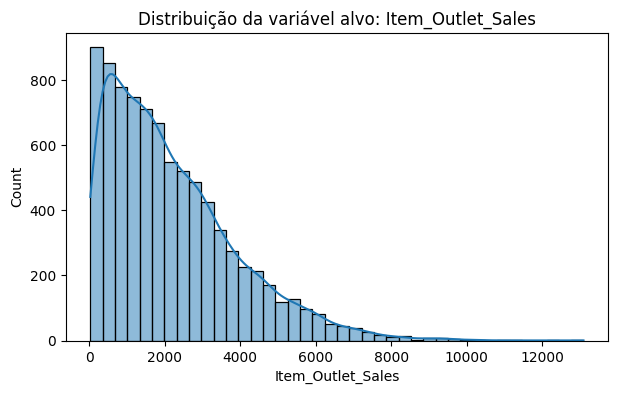

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(df['Item_Outlet_Sales'], bins=40, kde=True)
plt.title('Distribuição da variável alvo: Item_Outlet_Sales')
plt.show()


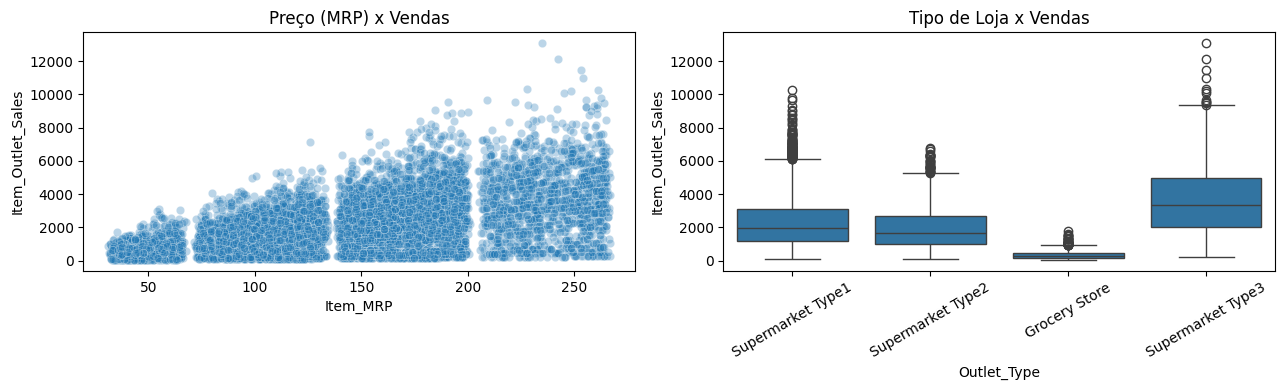

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.3, ax=axes[0])
axes[0].set_title('Preço (MRP) x Vendas')
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[1])
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Tipo de Loja x Vendas')
plt.tight_layout()
plt.show()


## 5. Preparação para o modelo: encoding + normalização + PCA

In [11]:
# Removendo identificadores, que não têm valor preditivo direto
df_modelo = df.drop(columns=['Item_Identifier', 'Outlet_Identifier'])

# Separando variável alvo
TARGET = df_modelo['Item_Outlet_Sales']
PREDITORAS = df_modelo.drop(columns=['Item_Outlet_Sales'])

# One-Hot Encoding das variáveis categóricas
PREDITORAS = pd.get_dummies(PREDITORAS, drop_first=True)
print("Número de variáveis após One-Hot Encoding:", PREDITORAS.shape[1])
PREDITORAS.head()


Número de variáveis após One-Hot Encoding: 27


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,True,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,8.93,0.000000,53.8614,1987,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [12]:
# Normalizando todas as variáveis preditoras (necessário antes do PCA)
normalizador = MinMaxScaler()
PREDITORAS_NORM = normalizador.fit_transform(PREDITORAS)


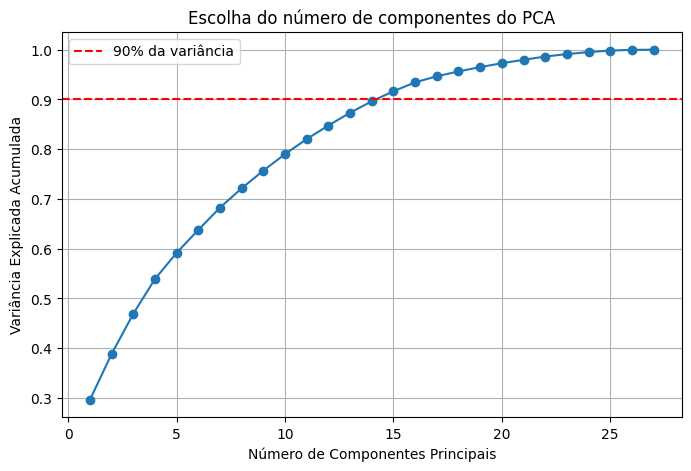

Número de componentes escolhido (>= 90% da variância): 15


In [13]:
# Avaliando quantos componentes principais são necessários para explicar ~90% da variância
pca_full = PCA().fit(PREDITORAS_NORM)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% da variância')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Escolha do número de componentes do PCA')
plt.legend()
plt.grid(True)
plt.show()

n_componentes = int(np.argmax(variancia_acumulada >= 0.90) + 1)
print(f"Número de componentes escolhido (>= 90% da variância): {n_componentes}")


In [14]:
pca = PCA(n_components=n_componentes)
PREDITORAS_PCA = pca.fit_transform(PREDITORAS_NORM)

PREDITORAS_PCA = pd.DataFrame(PREDITORAS_PCA, columns=[f'PC{i+1}' for i in range(n_componentes)])
PREDITORAS_PCA.shape


(8523, 15)

## 6. Divisão treino/teste

In [15]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    PREDITORAS_PCA, TARGET, test_size=0.3, random_state=42
)
X_treino.shape, X_teste.shape


((5966, 15), (2557, 15))

## 7. Treinando o modelo de regressão (Random Forest Regressor)

In [16]:
regressor = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
regressor.fit(X_treino, y_treino)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 8. Avaliação do modelo

In [17]:
previsoes = regressor.predict(X_teste)

rmse = np.sqrt(mean_squared_error(y_teste, previsoes))
mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")


RMSE: 1090.68
MAE:  764.24
R²:   0.5753


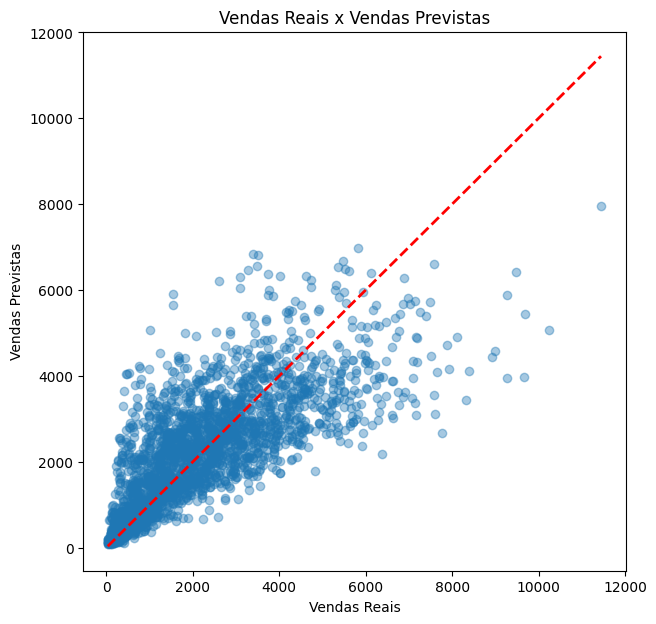

In [18]:
plt.figure(figsize=(7,7))
plt.scatter(y_teste, previsoes, alpha=0.4)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Vendas Reais')
plt.ylabel('Vendas Previstas')
plt.title('Vendas Reais x Vendas Previstas')
plt.show()


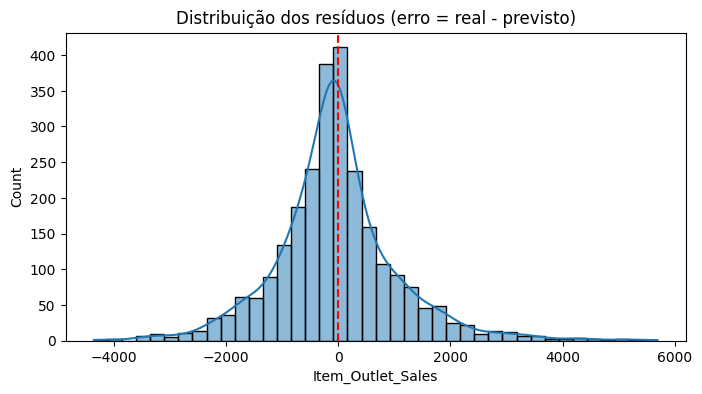

In [19]:
residuos = y_teste - previsoes
plt.figure(figsize=(8,4))
sns.histplot(residuos, bins=40, kde=True)
plt.title('Distribuição dos resíduos (erro = real - previsto)')
plt.axvline(0, color='red', linestyle='--')
plt.show()


## 9. Conclusões

O dataset tinha **8.523 produtos**. Depois do One-Hot Encoding das variáveis categóricas (tipo de produto, tipo/tamanho/localização da loja etc.), o número de colunas passou de 10 variáveis originais para **27 colunas**. O PCA reduziu essas 27 colunas para apenas **15 componentes principais**, preservando 90% da variância dos dados — ou seja, quase metade das colunas foi descartada sem perda relevante de informação.

**Resultados do modelo (Random Forest Regressor sobre os componentes do PCA):**
- RMSE: **1.090,68**
- MAE: **764,24**
- R²: **0,575**

Um R² de 0,575 indica que o modelo consegue explicar cerca de **57,5% da variação nas vendas** dos produtos a partir das características disponíveis (preço, peso, tipo de loja, localização etc.) — um resultado razoável para regressão em dados de varejo, mas que deixa claro que existem outros fatores não capturados no dataset (sazonalidade, promoções pontuais, estoque, concorrência local) que também influenciam a venda.

**Principais melhorias possíveis:** o preço do produto (`Item_MRP`) é historicamente a variável mais explicativa nesse dataset — vale testar o modelo também **sem PCA** (usando as 27 variáveis originais diretamente) para comparar se a redução de dimensionalidade custou alguma precisão, já que aqui o ganho de simplicidade (27 → 15 colunas) foi modesto e pode não compensar a perda de interpretabilidade das variáveis originais.
